In [120]:
using CSV: read, write
using DataFrames
using Statistics
using Plots

In [121]:
cd("/data2/mkhrenov/Hardness Measurements/WAAM Cylinders/")

In [122]:
index = read("WAAM Cylinders Index.csv", DataFrame; delim=",")

Row,Cylinder,Start Test Job (Pre),Finish Test Job (Pre),Start Test Job (Post),Finish Test Job (Post)
,Int64,Int64,Int64,Int64,Int64
1,1,2,5,115,117
2,2,6,9,73,75
3,3,10,13,94,96
4,4,22,25,106,108
5,5,18,21,88,90
6,6,26,29,70,72
7,7,30,33,112,114
8,8,34,37,97,99
9,9,38,41,79,81


In [123]:
cd("/data2/mkhrenov/Hardness Measurements/WAAM Cylinders/")
bad_points = readdir("Bad Points/")
bad_points = [match(r"Job ([0-9]+) Point ([0-9]+)", p) for p in bad_points]
bad_points = [(parse(Int, m[1]), parse(Int, m[2])) for m in bad_points]

bad_point_dict = Dict()
for (job, point) in bad_points
    if !haskey(bad_point_dict, job)
        bad_point_dict[job] = []
    end
    arr = bad_point_dict[job]
    push!(arr, point)
end
bad_points = bad_point_dict

for (job, points) in bad_points
    sort!(points)
end

In [124]:
comparison_df = DataFrame(Cylinder=Int[], Point=Int[], InitialHardnessMean=Float64[], InitialHardnessStdev=Float64[], FinalHardnessMean=Float64[], FinalHardnessStdev=Float64[])
allowmissing!(comparison_df)

for row in eachrow(index)
    cylinder, pre_start, pre_stop, post_start, post_stop = row
    num_points = min(pre_stop - pre_start, post_stop - post_start) + 1

    for point in 1:num_points
        init_hardness_mean, init_hardness_stdev, final_hardness_mean, final_hardness_stdev = missing, missing, missing, missing

        job = pre_start + point - 1
        if isfile("WAAM Cylinders - Test job # $(job).csv")
            hardness_df = read("WAAM Cylinders - Test job # $(job).csv", DataFrame; delim=",")
            if haskey(bad_points, job)
                delete!(hardness_df, bad_points[job])
            end
            dropmissing!(hardness_df)
            init_hardness_mean = mean(hardness_df[:, "HV"])
            init_hardness_stdev = std(hardness_df[:, "HV"]) / sqrt(length(eachrow(hardness_df))) * 1.98
        end

        job = post_start + point - 1
        if isfile("WAAM Cylinders - Test job # $(job).csv")
            hardness_df = read("WAAM Cylinders - Test job # $(job).csv", DataFrame; delim=",")
            if haskey(bad_points, job)
                delete!(hardness_df, bad_points[job])
            end
            dropmissing!(hardness_df)
            final_hardness_mean = mean(hardness_df[:, "HV"])
            final_hardness_stdev = std(hardness_df[:, "HV"]) / sqrt(length(eachrow(hardness_df))) * 1.98
        end


        push!(comparison_df, (cylinder, point, init_hardness_mean, init_hardness_stdev, final_hardness_mean, final_hardness_stdev))
    end
end

write("hardness_comparison.csv", comparison_df)


"hardness_comparison.csv"

In [125]:
comparison_df[1:24,:]

Row,Cylinder,Point,InitialHardnessMean,InitialHardnessStdev,FinalHardnessMean,FinalHardnessStdev
,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?
1,1,1,248.312,6.18806,255.365,3.94332
2,1,2,237.642,7.3285,243.882,4.07476
3,1,3,273.871,10.1088,267.307,5.51877
4,2,1,236.832,3.02706,244.049,3.39756
5,2,2,255.61,4.51814,234.843,4.52739
6,2,3,281.587,5.89679,277.084,5.32513
7,3,1,238.342,3.82427,248.482,3.16674
8,3,2,235.66,5.63967,227.625,3.57587
9,3,3,245.396,6.80085,225.99,3.1584


In [126]:
comparison_df[25:end,:]

Row,Cylinder,Point,InitialHardnessMean,InitialHardnessStdev,FinalHardnessMean,FinalHardnessStdev
,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?
1,9,1,244.071,3.69899,195.145,1.73108
2,9,2,272.589,5.21031,182.559,2.61256
3,9,3,269.514,3.96672,193.092,2.2673
4,10,1,233.733,4.28585,200.566,2.68994
5,10,2,273.258,6.47145,199.398,2.06416
6,10,3,291.042,5.46056,199.592,3.65003
7,11,1,269.223,3.81935,239.188,3.83091
8,11,2,260.01,4.31429,183.841,1.76877
9,11,3,264.69,3.62272,186.644,1.73222


In [127]:
dropmissing!(comparison_df)
@show maximum(comparison_df[:, "InitialHardnessMean"])
@show minimum(comparison_df[:, "InitialHardnessMean"])
@show maximum(comparison_df[:, "FinalHardnessMean"])
@show minimum(comparison_df[:, "FinalHardnessMean"])
Hmax = 380.0
Hmin = 140.0

filter!(row -> row.InitialHardnessMean ≤ Hmax, comparison_df)
comparison_df[:, 3] .= Hmax .- comparison_df[:, 3]
comparison_df[:, 5] .= Hmax .- comparison_df[:, 5]
comparison_df[:, 3:end] ./= (Hmax - Hmin)
comparison_df

maximum(comparison_df[:, "InitialHardnessMean"]) = 357.90274375
minimum(comparison_df[:, "InitialHardnessMean"]) = 220.2429125
maximum(comparison_df[:, "FinalHardnessMean"]) = 349.55873125
minimum(comparison_df[:, "FinalHardnessMean"]) = 158.63054375000002


Row,Cylinder,Point,InitialHardnessMean,InitialHardnessStdev,FinalHardnessMean,FinalHardnessStdev
,Int64,Int64,Float64,Float64,Float64,Float64
1,1,1,0.548699,0.0257836,0.519314,0.0164305
2,1,2,0.593157,0.0305354,0.56716,0.0169782
3,1,3,0.442203,0.04212,0.469554,0.0229949
4,2,1,0.596535,0.0126128,0.566461,0.0141565
5,2,2,0.518293,0.0188256,0.60482,0.0188641
6,2,3,0.410055,0.02457,0.428817,0.022188
7,3,1,0.590242,0.0159345,0.547991,0.0131947
8,3,2,0.601418,0.0234986,0.634897,0.0148995
9,3,3,0.560851,0.0283369,0.64171,0.01316


In [128]:
n = .05
transform_ratio = ((-log.(1 .- comparison_df[:, 5])).^(1/n)) .- ((-log.(1 .- comparison_df[:, 3])).^(1/n))
comparison_df[!, :TransformRatio] = transform_ratio

48-element Vector{Float64}:
     -0.0083505041174264
     -0.09102812593447762
      8.91096948001038e-5
     -0.11639382430117878
      0.2245119020399315
      6.408052127966181e-6
     -0.09219235292266867
      0.9748542494723497
      1.6640853535147866
     53.26414898696143
      ⋮
    469.03064283459287
      1.3401249245797336e7
 146041.69046963667
   2518.40886114388
 474689.53770967905
      3.7813225289422343e6
   3339.471412178348
      4.0567430083352e7
      1.4146908296171233e8

In [129]:
filter!(row -> row.TransformRatio > 0.0, comparison_df)
comparison_df[!, :LnLnTransformRatio] = log.(comparison_df[:, :TransformRatio])

43-element Vector{Float64}:
  -9.325642421324707
  -1.4938265574370453
 -11.957955213405121
  -0.025467306879359837
   0.5092756352630746
   3.9752634779705684
  -2.219333045193678
  -5.144404022440937
   6.324755662783168
   7.658898531185571
   ⋮
   6.150668102846254
  16.410858487874055
  11.891647411090394
   7.831382576777838
  13.070416264502299
  15.145584381785195
   8.113567813619497
  17.5184760879298
  18.76759175620383

In [130]:
cd("/data2/mkhrenov/Gleeble Thermal Data/")

In [131]:
bad_thermocouples = [(3,1), (4,1), (6,2), (14,2), (15,1)] 
bad_points = vcat(bad_thermocouples, [(1,1), (1,2), (1,3), (2,1), (2,3), (3,1), (4,3), (6,1), (7,3), (8,1), (8,2), (8,3), (10,1), (10,2), (10,3), (11,1), (11,2), (11,3)])
temperature_df = DataFrame(Cylinder=Int[], Point=Int[], Time=Float64[], Temperature=Float64[])
p = []
temp_histories = readdir(".")
for temp_hist in temp_histories
    temp_df = read(temp_hist, DataFrame; delim=",", skipto=3)

    m = match(r"WAAM_Rod_([0-9]+)_.*?_([0-9]+)min.csv", temp_hist)
    cylinder = parse(Int, m[1])

    time = parse(Int, m[2]) * 60

    t1 = median(temp_df[:, :TC1][(20*500):((20+time)*500)]) + 273.15
    t2 = median(temp_df[:, :TC2][(20*500):((20+time)*500)]) + 273.15
    t3 = median(temp_df[:, :TC3][(20*500):((20+time)*500)]) + 273.15
    time += 0

    if !((cylinder, 1) in bad_points)
        push!(temperature_df, (cylinder, 1, time, t1))
    end
    if !((cylinder, 2) in bad_points)
        push!(temperature_df, (cylinder, 2, time, t2))
    end
    if !((cylinder, 3) in bad_points)
        push!(temperature_df, (cylinder, 3, time, t3))
    end
end

temperature_df

Row,Cylinder,Point,Time,Temperature
,Int64,Int64,Float64,Float64
1,12,1,2400.0,582.568
2,12,2,2400.0,844.886
3,12,3,2400.0,850.141
4,13,1,300.0,835.678
5,13,2,300.0,979.703
6,13,3,300.0,950.146
7,14,1,600.0,843.771
8,14,3,600.0,950.15
9,15,2,1200.0,905.589


In [132]:
combined_df = innerjoin(comparison_df, temperature_df, on=[:Cylinder, :Point])
combined_df[1:end, :]


Row,Cylinder,Point,InitialHardnessMean,InitialHardnessStdev,FinalHardnessMean,FinalHardnessStdev,TransformRatio,LnLnTransformRatio,Time,Temperature
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2,2,0.518293,0.0188256,0.60482,0.0188641,0.224512,-1.49383,600.0,654.803
2,3,2,0.601418,0.0234986,0.634897,0.0148995,0.974854,-0.0254673,1200.0,638.129
3,3,3,0.560851,0.0283369,0.64171,0.01316,1.66409,0.509276,1200.0,650.135
4,4,2,0.358677,0.033835,0.59138,0.0120722,0.108682,-2.21933,2400.0,608.302
5,5,1,0.526161,0.0185123,0.74639,0.0143512,558.221,6.32476,300.0,613.989
6,5,2,0.486386,0.0213289,0.769291,0.00830333,2119.42,7.6589,300.0,745.293
7,5,3,0.606127,0.0247282,0.698805,0.0129747,38.0937,3.64005,300.0,750.156
8,6,3,0.566993,0.00771172,0.698449,0.0122831,37.5605,3.62595,600.0,750.151
9,7,1,0.443606,0.020643,0.557625,0.0209876,0.0169402,-4.07806,1200.0,543.769


In [133]:
combined_df[25:end,:]

Row,Cylinder,Point,InitialHardnessMean,InitialHardnessStdev,FinalHardnessMean,FinalHardnessStdev,TransformRatio,LnLnTransformRatio,Time,Temperature
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,16,2,0.513802,0.0194016,0.909381,0.00521827,4.05674e7,17.5185,2400.0,953.717
2,16,3,0.564938,0.0136471,0.922373,0.00388958,1.41469e8,18.7676,2400.0,950.15


y = [-7.890756212653192, -7.115544142655452, -6.580801200513017, -10.002557061529714, 0.6209731881269667, 1.95511605652937, -2.0637345249422876, -2.770976706687766, -11.168140602422149, 1.4906654353354938, 2.010590084576892, 5.2558053797802575, 2.5201141840344565, -5.139955229361695, 3.579817850001241, 7.50110951190425, 3.2626633773043867, 9.081446248089996, 9.81999590778056, -0.24626155236989256, 5.494717755874248, 5.980339428726207, 8.055507546009103, 0.33034379728345975, 9.735252071593761, 10.984367739867794]
E = -negE_R * cR = 198676.6040848352
lnA = 32.583576112692704
A = exp(lnA) = 1.415361266858504e14
(√SSres / length(y)) * (Hmax - Hmin) = 129.5411232782944


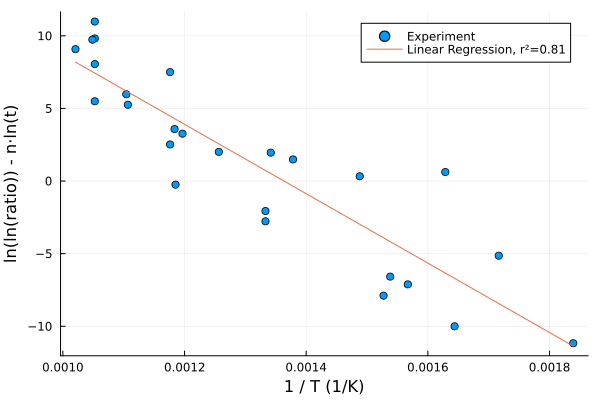

In [134]:
cR = 8.314

y = combined_df[:, :LnLnTransformRatio] .- log.(combined_df[:, :Time])

@show y
X = hcat(1 ./ (combined_df[:, :Temperature]), ones(length(y)))
Θ = X \ y
negE_R, lnA = Θ
@show E = -negE_R * cR # J/mol
@show lnA
@show A = exp(lnA) # unitless
ȳ = mean(y)
SSres = sum((y .- X * Θ) .^ 2)
SStot = sum((y .- ȳ) .^ 2)
r² = 1 - SSres / SStot

@show √(SSres) / length(y) * (Hmax - Hmin)

scatter(X[:, 1], y , label="Experiment")
plot!((t) -> negE_R * t + lnA, label="Linear Regression, r²=$(round(r², digits=2))")
xlabel!("1 / T (1/K)")
ylabel!("ln(ln(ratio)) - n⋅ln(t)")

In [135]:
include("../../../src/sysid.jl")

good_thermocouples = [(row[:Cylinder], row[:Point]) for row in eachrow(combined_df)]

y₀ = []
ȳ = []
y₀_dict = Dict(zip(zip(combined_df[:, :Cylinder], combined_df[:, :Point]), combined_df[:, :InitialHardnessMean]))
ȳ_dict = Dict(zip(zip(combined_df[:, :Cylinder], combined_df[:, :Point]), combined_df[:, :FinalHardnessMean]))

dts::Vector{Vector{Float64}} = []
Ts::Vector{Vector{Float64}} = []
Δt = 0.25

H₀ = Hmin
H₁ = Hmax
@show θ₀ = [n * lnA, 1 / n, n * E / 1e3] #unitless, kJ 

for temp_hist in temp_histories
    temp_df = read(temp_hist, DataFrame; delim=",", skipto=3)

    m = match(r"WAAM_Rod_([0-9]+)_.*?_([0-9]+)min.csv", temp_hist)
    cylinder = parse(Int, m[1])

    t = temp_df[1:125:end, :Time]
    T1 = temp_df[1:125:end, :TC1] .+ 273.15
    T2 = temp_df[1:125:end, :TC2] .+ 273.15
    T3 = temp_df[1:125:end, :TC3] .+ 273.15

    # plot(t, T1, label=nothing, xlabel="Time (s)", ylabel="T (K)", title="Cylinder $(cylinder), Point 1")
    # savefig("$(cylinder)_1.png")
    # plot(t, T2, label=nothing, xlabel="Time (s)", ylabel="T (K)", title="Cylinder $(cylinder), Point 2")
    # savefig("$(cylinder)_2.png")
    # plot(t, T3, label=nothing, xlabel="Time (s)", ylabel="T (K)", title="Cylinder $(cylinder), Point 3")
    # savefig("$(cylinder)_3.png")

    dt = t[2:end] .- t[1:(end-1)]
    T1 = T1[2:end]
    T2 = T2[2:end]
    T3 = T3[2:end]


    if (cylinder, 1) in good_thermocouples
        push!(dts, dt)
        push!(Ts, T1)
        push!(y₀, y₀_dict[(cylinder, 1)])
        push!(ȳ, ȳ_dict[(cylinder, 1)])
    end
    if (cylinder, 2) in good_thermocouples
        push!(dts, dt)
        push!(Ts, T2)
        push!(y₀, y₀_dict[(cylinder, 2)])
        push!(ȳ, ȳ_dict[(cylinder, 2)])
    end
    if (cylinder, 3) in good_thermocouples
        push!(dts, dt)
        push!(Ts, T3)
        push!(y₀, y₀_dict[(cylinder, 3)])
        push!(ȳ, ȳ_dict[(cylinder, 3)])
    end
end


θ₀ = [n * lnA, 1 / n, (n * E) / 1000.0] = [1.6291788056346352, 20.0, 9.933830204241762]


In [136]:
y₀
# θ₀ = [35.99057747481247 * 0.07556318185727504, 1 / 0.07556318185727504, 251.24337533269426 * 0.07556318185727504]

26-element Vector{Any}:
 0.625345546875
 0.5764855833333334
 0.6656545312500001
 0.3970983593750001
 0.4648526302083335
 0.5134359114583333
 0.3858635156249998
 0.41088590277777753
 0.6273428645833334
 0.6341730468750001
 ⋮
 0.5261608333333332
 0.48638562500000027
 0.6061270833333333
 0.5669925694444443
 0.4436055833333332
 0.619506015625
 0.5663720052083332
 0.4475450781249999
 0.4603566145833334

In [137]:
prob = SYSID_Problem(dts, Ts, ȳ; y₀=y₀)
yf0 = simulate(prob, θ₀)
@show yf0
@show prob.ȳ
@show √(sum((yf0 .- prob.ȳ) .^ 2)) / length(ȳ)

yf0 = [0.6930550680030917, 0.8396812422675353, 0.8422282120134693, 0.8203193068477359, 0.8643513396781967, 0.8555176139136559, 0.8231056343327753, 0.8645674299789985, 0.8583366573103626, 0.8736637661723761, 0.7552144022413211, 0.8834536000430618, 0.8824514272874333, 0.6776649272674176, 0.6745148290531686, 0.6859915643376642, 0.6535829372985762, 0.671846211889149, 0.745065278425272, 0.7492671900725589, 0.7606953259533633, 0.6393784345853888, 0.7550291727205773, 0.7787898472128343, 0.8346689915066725, 0.8112464766875996]
prob.ȳ = [0.6814702777777778, 0.8288136458333335, 0.8832022916666668, 0.7910547916666667, 0.8768544270833334, 0.8861842447916666, 0.7433562239583332, 0.8367175781249999, 0.8537294270833334, 0.8814554427083333, 0.7769414236111112, 0.9093810937500001, 0.9223727343749999, 0.6048202343749999, 0.6348965364583333, 0.6417098958333335, 0.5913795833333333, 0.7463897916666669, 0.7692908072916665, 0.6988053906249997, 0.6984493750000003, 0.5576247135416667, 0.7847134375, 0.770228906

0.008421790940327085

In [138]:
θ = fit_avrami(prob, θ₀, [-Inf, 0.0, 0.0], [Inf, Inf, Inf]; solv="mumps", tol=1e-5, max_iter=50_000)
# write("theta.txt", θ)
θ

Nz = 3
Checking objective function...
  0.005656 seconds (53 allocations: 5.242 KiB)
  0.005605 seconds (55 allocations: 5.641 KiB)
Checking objective gradient...
  0.356871 seconds (930.28 k allocations: 63.665 MiB, 2.90% gc time, 98.00% compilation time)
  0.007014 seconds (59 allocations: 7.422 KiB)
gt = [0.7550408612352036, -0.010436283336375253, -0.14356811732025512]
This is Ipopt version 3.14.13, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        9

Total number of variables............................:        3
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints..

3×3 Matrix{Float64}:
 25.9657   -0.39163     -3.92003
 -0.39163   0.00733848   0.0588481
 -3.92003   0.0588481    0.604124

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
3-element Vector{Float64}:
  0.0014241824429168787
  0.012052154314731698
 26.563698243459594
vectors:
3×3 Matrix{Float64}:
 -0.0189571   0.148869  -0.988675
 -0.99949    -0.028248   0.014911
 -0.0257083   0.988453   0.149329

3-element Vector{Float64}:
  1.9606495682866854
 19.383757547464462
 12.394121255945656

In [139]:
yf = simulate(prob, θ)
@show yf
@show prob.ȳ
@show √(sum((yf .- prob.ȳ) .^ 2) / length(ȳ)) * (Hmax - Hmin)

yf = [0.6736968249980815, 0.8378087792536366, 0.8409983843127302, 0.823625977044165, 0.8742348723601636, 0.8635122298090525, 0.8229236600724326, 0.8726037601499066, 0.8632497956773587, 0.8817005845658693, 0.7480020784406749, 0.891660666708012, 0.8904541908779299, 0.6371072143312605, 0.6338968745756071, 0.6450631043223023, 0.6021040239778893, 0.642951247319151, 0.7250163768942093, 0.7303824134544086, 0.7424076732036562, 0.6052875769322126, 0.7329045112957346, 0.7685466241874256, 0.8383521592673397, 0.8088283815129883]
prob.ȳ = [0.6814702777777778, 0.8288136458333335, 0.8832022916666668, 0.7910547916666667, 0.8768544270833334, 0.8861842447916666, 0.7433562239583332, 0.8367175781249999, 0.8537294270833334, 0.8814554427083333, 0.7769414236111112, 0.9093810937500001, 0.9223727343749999, 0.6048202343749999, 0.6348965364583333, 0.6417098958333335, 0.5913795833333333, 0.7463897916666669, 0.7692908072916665, 0.6988053906249997, 0.6984493750000003, 0.5576247135416667, 0.7847134375, 0.77022890625

8.96147935391874

In [140]:
# plotlyjs()
n = 1 / θ[2]
lnA = θ[1] / n
E = θ[3] / n
lnA, n, E

(38.00475586720998, 0.05158958460718094, 240.24464143912633)

In [141]:
# plot(7.0:0.5:9.0, 4.0:0.2:7.0, (x, y) -> MOI.eval_objective(prob, [x, y, E/1e3]), st=:surface)

In [142]:
# plot(7.0:0.5:9.0, 60.0:120.0, (x, y) -> MOI.eval_objective(prob, [x, 1/n, y]), st=:surface)

In [143]:
# plot(3.0:0.5:8.0, 60.0:120.0, (x, y) -> MOI.eval_objective(prob, [lnA, x, y]), st=:surface)

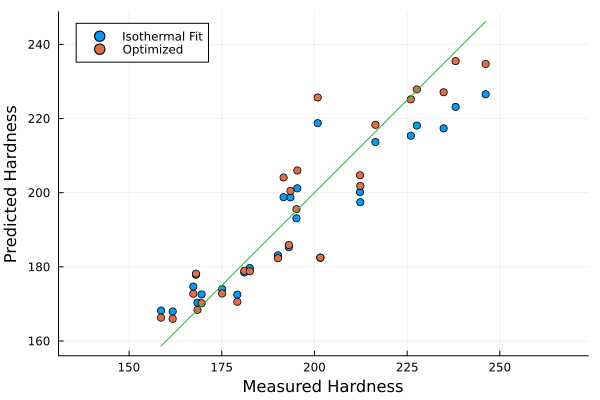

In [144]:
plot(xlabel="Measured Hardness", ylabel="Predicted Hardness", aspect_ratio=:equal)
scatter!(Hmax .- (Hmax - Hmin) .* ȳ, Hmax .- (Hmax - Hmin) .* yf0, label="Isothermal Fit")
scatter!(Hmax .- (Hmax - Hmin) .* ȳ, Hmax .- (Hmax - Hmin) .* yf, label="Optimized")
plot!(t -> t, label=nothing)
# cd("/home/mkhrenov/Downloads/")
# savefig("linecomp.png")

In [145]:
SSres = sum((ȳ .- yf) .^ 2)
SStot = sum((ȳ .- mean(ȳ)) .^ 2)
r² = 1 - SSres / SStot

0.8654835387204446

In [146]:
SSres = sum((ȳ .- yf0) .^ 2)
SStot = sum((ȳ .- mean(ȳ)) .^ 2)
r² = 1 - SSres / SStot

0.8220816423614633

In [147]:
err = (ȳ .- yf) .* (Hmax - Hmin)
err0 = (ȳ .- yf0) .* (Hmax - Hmin)
err_mean = mean(err)
err_var = std(err)^2
err0_mean = mean(err0)
err0_var = std(err0)^2

101.25826364545141

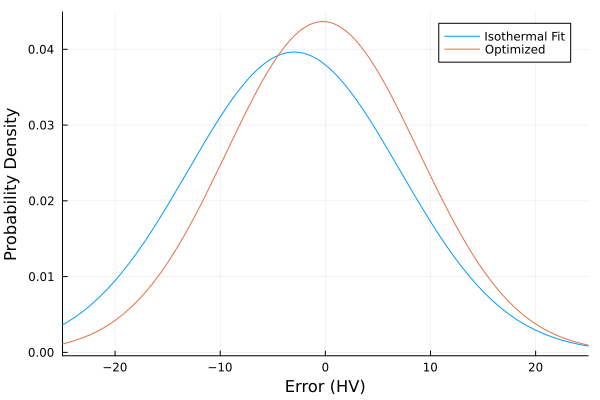

In [148]:
n_pdf(x, μ, σ²) = 1 / √(2π*σ²) * exp(-(x - μ)^2/(2σ²))

plot(xlim = (-25, 25), xlabel="Error (HV)", ylabel="Probability Density")
plot!(x -> n_pdf(x, err0_mean, err0_var),label="Isothermal Fit")
plot!(x -> n_pdf(x, err_mean, err_var), label="Optimized")
# cd("/home/mkhrenov/Downloads/")
# savefig("bellcomp.png")